### Time to get your hands dirty. SDSS Galaxies vs quasars

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 
#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new in computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [1]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from astroML.utils import completeness_contamination
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

In [2]:
df = pd.read_csv(filepath_or_buffer= '/home/matti/uni/astrostatistics_bicocca_2026/solutions/galaxyquasar.csv')

In [3]:
df

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [4]:
#magnitude measurements of differrent wavelenght
u = np.array(df['u'])
g = np.array(df['g'])
r = np.array(df['r'])
i = np.array(df['i'])
z = np.array(df['z'])
cl = np.array(df['class'])
z1 = np.array(df['z1'])
zerr = np.array(df['zerr'])

In [5]:
def class_01(vec):
    for i in range (len(vec)):
        if (vec[i] == 'GALAXY'): vec[i] = int(0)
        if (vec[i] == 'QSO'): vec[i] = int(1)
    return vec.astype(int)
        

cl = class_01(cl)

In [6]:
#I need a 4 vector color vector
X = np.column_stack([u - g, g - r, r - i, i - z])


LDA - Completeness: 0.9397, Contamination: 0.0752
QDA - Completeness: 0.9352, Contamination: 0.0745


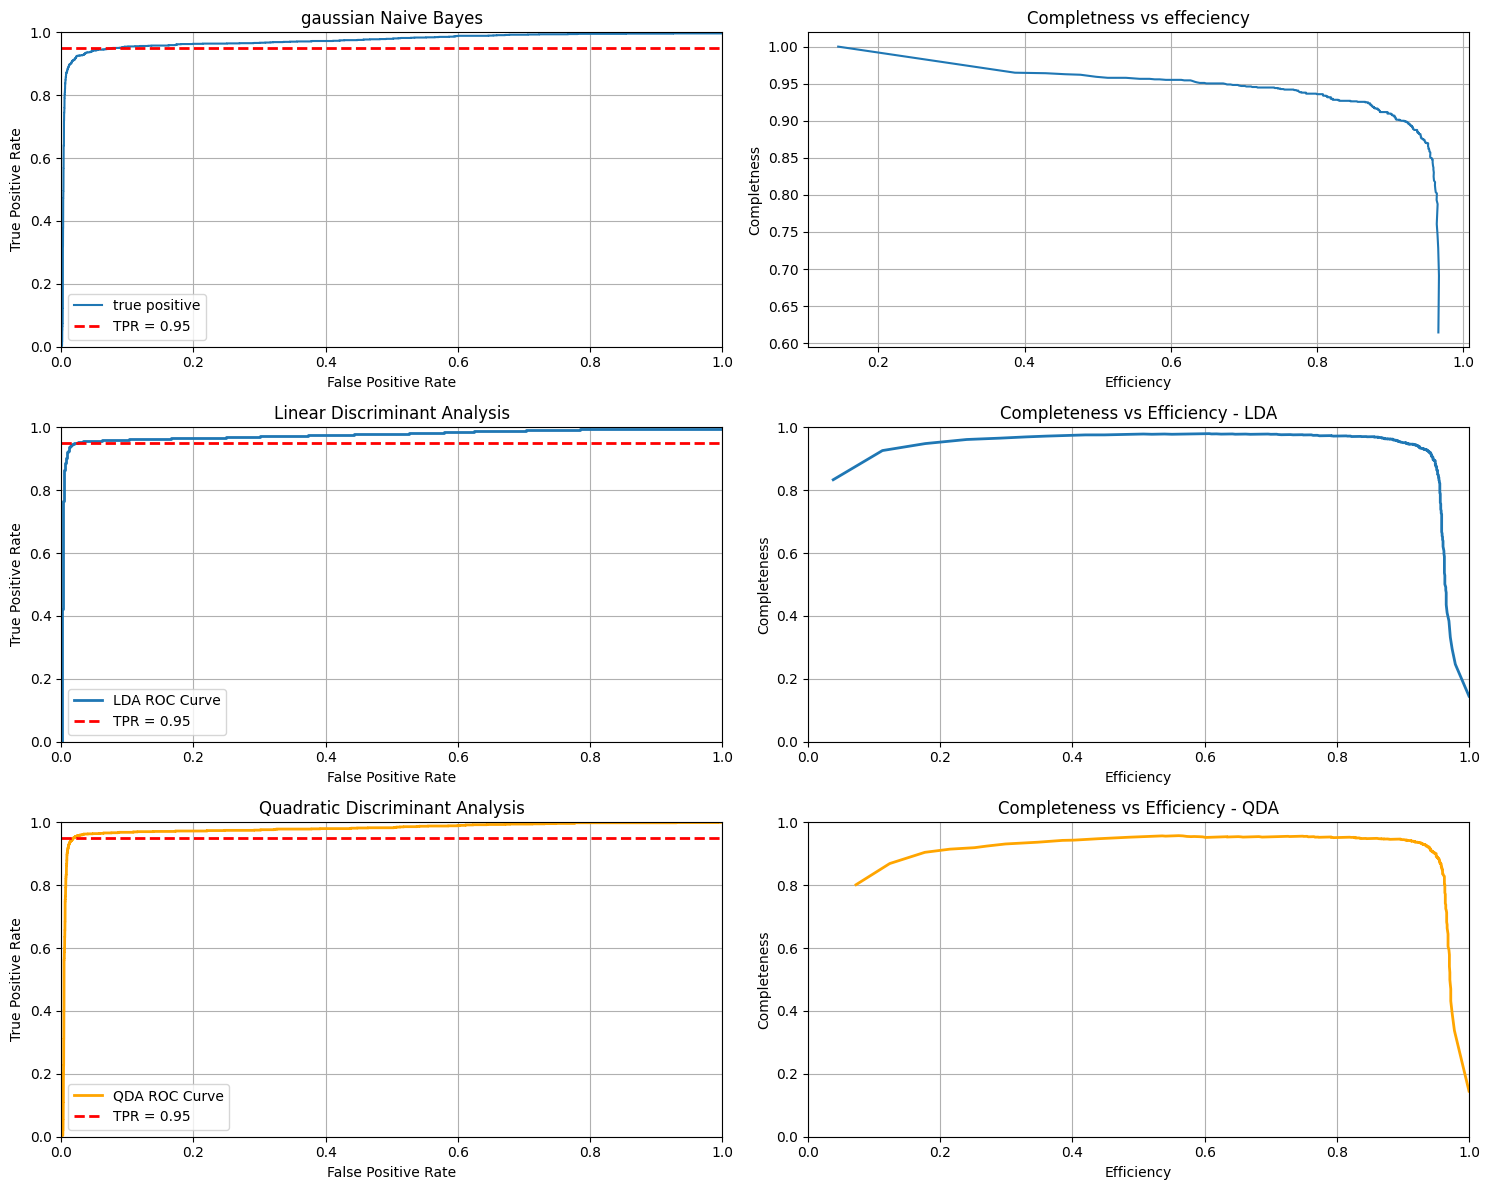

In [7]:

X_train, X_test, y_train, y_test = train_test_split(X, cl, test_size= 0.20)
clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1] 

com, cont = completeness_contamination(y_test, y_pred)

# Calculate ROC curve
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)

thresholds = np.linspace(0, 1, 1001)[:-1]
comp = np.zeros_like(thresholds)
cont = np.zeros_like(thresholds)
for i, t in enumerate(thresholds):
    y_pred = (y_pred_proba >= t)
    comp[i], cont[i] = completeness_contamination(y_pred, y_test)


lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

# Train both models
lda.fit(X_train, y_train)
qda.fit(X_train, y_train)

# Get predictions and probabilities
y_pred_lda = lda.predict(X_test)
y_pred_proba_lda = lda.predict_proba(X_test)[:, 1]

y_pred_qda = qda.predict(X_test)
y_pred_proba_qda = qda.predict_proba(X_test)[:, 1]

# Calculate completeness and contamination for both models
com_lda, cont_lda = completeness_contamination(y_test, y_pred_lda)
com_qda, cont_qda = completeness_contamination(y_test, y_pred_qda)

print(f"LDA - Completeness: {com_lda:.4f}, Contamination: {cont_lda:.4f}")
print(f"QDA - Completeness: {com_qda:.4f}, Contamination: {cont_qda:.4f}")

# Calculate ROC curves
fpr_lda, tpr_lda, threshold_lda = roc_curve(y_test, y_pred_proba_lda)
fpr_qda, tpr_qda, threshold_qda = roc_curve(y_test, y_pred_proba_qda)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
ax1 = axes[0, 0]
ax1.plot(fpr, tpr, label = 'true positive')
ax1.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='TPR = 0.95')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('gaussian Naive Bayes')
ax1.legend()
ax1.grid()
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax2 = axes[0, 1]
ax2.plot(1 - cont, comp, )
ax2.set_xlabel('Efficiency')
ax2.set_ylabel('Completness')
ax2.set_title('Completness vs effeciency')
ax2.grid()


ax3 = axes[1, 0]
ax3.plot(fpr_lda, tpr_lda, label='LDA ROC Curve', linewidth=2)
ax3.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='TPR = 0.95')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('Linear Discriminant Analysis')
ax3.legend()
ax3.grid()
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])

# Completeness vs Efficiency for LDA
ax4 = axes[1, 1]
thresholds = np.linspace(0, 1, 1001)[:-1]
comp_lda = np.zeros_like(thresholds)
cont_lda_curve = np.zeros_like(thresholds)
for i, t in enumerate(thresholds):
    y_pred_thresh = (y_pred_proba_lda >= t)
    comp_lda[i], cont_lda_curve[i] = completeness_contamination(y_test, y_pred_thresh)

ax4.plot(1 - cont_lda_curve, comp_lda, linewidth=2)
ax4.set_xlabel('Efficiency')
ax4.set_ylabel('Completeness')
ax4.set_title('Completeness vs Efficiency - LDA')
ax4.grid()
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

# ============ QDA ============
# ROC Curve for QDA
ax5 = axes[2, 0]
ax5.plot(fpr_qda, tpr_qda, label='QDA ROC Curve', linewidth=2, color='orange')
ax5.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='TPR = 0.95')
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('Quadratic Discriminant Analysis')
ax5.legend()
ax5.grid()
ax5.set_xlim([0, 1])
ax5.set_ylim([0, 1])

# Completeness vs Efficiency for QDA
ax6 = axes[2, 1]
comp_qda = np.zeros_like(thresholds)
cont_qda_curve = np.zeros_like(thresholds)
for i, t in enumerate(thresholds):
    y_pred_thresh = (y_pred_proba_qda >= t)
    comp_qda[i], cont_qda_curve[i] = completeness_contamination(y_test, y_pred_thresh)

ax6.plot(1 - cont_qda_curve, comp_qda, linewidth=2, color='orange')
ax6.set_xlabel('Efficiency')
ax6.set_ylabel('Completeness')
ax6.set_title('Completeness vs Efficiency - QDA')
ax6.grid()
ax6.set_xlim([0, 1])
ax6.set_ylim([0, 1])

plt.tight_layout()
plt.tight_layout()



In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
X_temp, x_test, y_temp, y_test = train_test_split(X, cl, test_size=0.20)

NB = GaussianNB()
LDA = LinearDiscriminantAnalysis()
QDA = QuadraticDiscriminantAnalysis()
models = [NB, LDA, QDA]

kfold = KFold(n_splits = 3, shuffle = True)

cv_scores = []
test_scores = []
for model in models:
    for (train_index, test_index) in (kfold.split(X_train)):
        x_train, x_cv_test = X_temp[train_index], X_temp[test_index]
        y_train, y_cv_test = y_temp[train_index], y_temp[test_index]
        model.fit(x_train, y_train)
        y_cv_pred = model.predict( x_cv_test )
        y_test_pred = model.predict(x_test)
        y_pred_proba = model.predict_proba(x_cv_test)[:, 1]
        cv_score = mean_squared_error(y_cv_test, y_cv_pred)
        test_score = mean_squared_error(y_test, y_test_pred)
        cv_scores.append(cv_score)
        test_scores.append(test_score)
    avg_cv = np.mean(cv_scores)
    avg_test = np.mean(test_scores)
    print(f"Model: {type(model).__name__} | Avg cv MSE: {avg_cv:.4f} | Avg test MSE: {avg_test:.4f}")



Model: GaussianNB | Avg cv MSE: 0.0293 | Avg test MSE: 0.0264
Model: LinearDiscriminantAnalysis | Avg cv MSE: 0.0239 | Avg test MSE: 0.0221
Model: QuadraticDiscriminantAnalysis | Avg cv MSE: 0.0226 | Avg test MSE: 0.0212


quadraticDiscriminantAnalyses seems the best, but they are quite similar

[array(0.93493635), array(0.89802855), array(0.88918558), array(0.85852713)] [array(0.07422969), array(0.07492997), array(0.06722689), array(0.06932773)]


Text(0, 0.5, 'contamination')

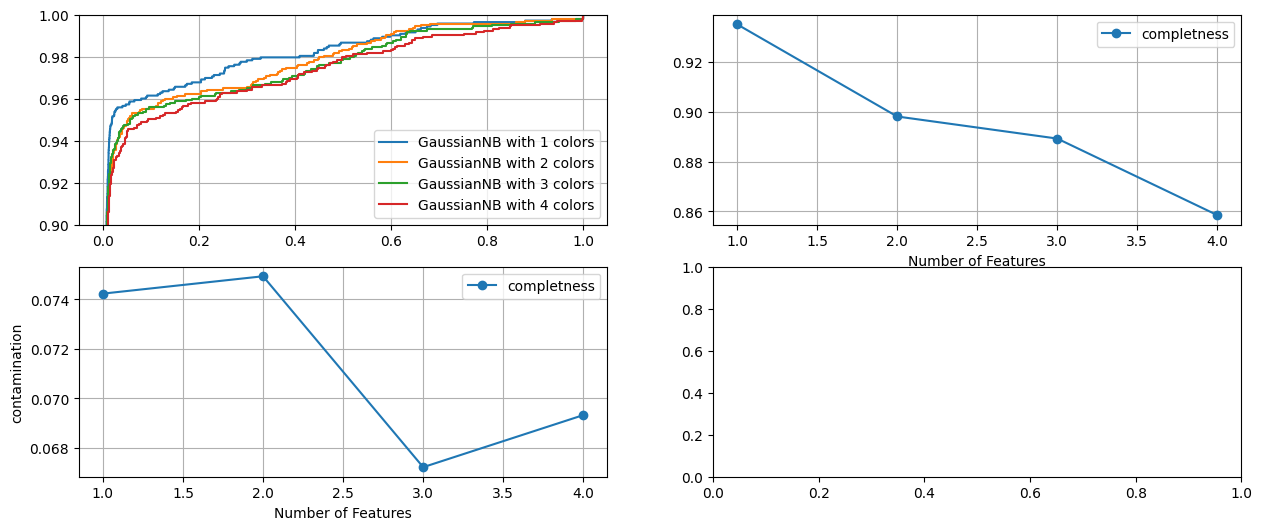

In [27]:
#now implement adding subset to subset for gaussian Naive Bayes

colors = (u, g, r, i, z)


features = []
for j in range(4):
    features.append(colors[j] - colors[j + 1])

# Shape: (n_samples, 4)
X_all = np.array(features).T

completeness_values = []
contamination_values = []

fig, (ax) = plt.subplots(nrows = 2, ncols = 2, figsize=(15, 6))
ax1 = ax[0, 0]
ax2 = ax [0, 1]
ax3 = ax[1, 0]
for n_features in range(1, 5):

    X = X_all[:, :n_features]

    X_train, X_test, y_train, y_test = train_test_split(
        X, cl, test_size=0.2, random_state=42
    )

    NB = GaussianNB()
    NB.fit(X_train, y_train)

    y_pred = NB.predict(X_test)
    
    y_pred_proba = NB.predict_proba(X_test)[:, 1]

    comp, cont = completeness_contamination(y_test, y_pred)
    completeness_values.append(comp)
    contamination_values.append(cont)

    fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
    thresholds = np.linspace(0, 1, 1001)[:-1]
    # comp = np.zeros_like(thresholds)
    # cont = np.zeros_like(thresholds)
    # for i, t in enumerate(thresholds):
    #     y_pred = (y_pred_proba >= t)
    #     comp[i], cont[i] = completeness_contamination(y_pred, y_test)

    ax1.plot(fpr, tpr, label = f'GaussianNB with {n_features} colors')
    
    # ax2.plot(1 - cont, comp, label = f'GaussianNB with {n_features} colors')

# ax1.set_xlim(0, 0.2)
ax1.set_ylim(0.9, 1)
ax1.grid()
ax1.legend()
ax2.plot(range(1, 5), completeness_values, marker='o', label = 'completness')
# ax2.plot(range(1, 5), contamination_values, marker='o', label = 'contamination')
ax2.set_xlabel('Number of Features')
ax2.legend()
ax2.grid()
print(completeness_values, contamination_values)
ax3.plot(range(1, 5), contamination_values, marker='o', label = 'completness')
ax3.grid()
ax3.set_xlabel('Number of Features')
ax3.legend()
ax3.set_ylabel('contamination')

devo implementarlo con un kfold

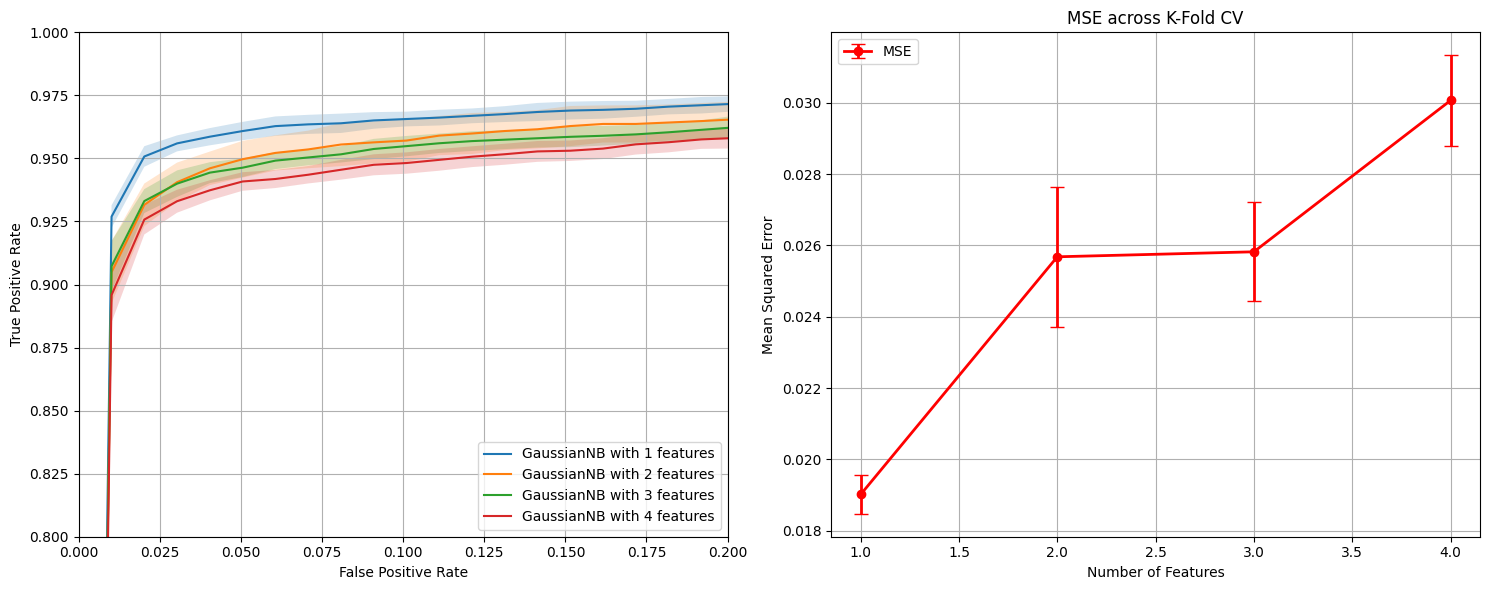

kfold MSE results
1 features: 0.019020 ± 0.000542
2 features: 0.025680 ± 0.001961
3 features: 0.025820 ± 0.001385
4 features: 0.030060 ± 0.001267


In [21]:


mse_values = []      # Mean MSE across folds
mse_std = []         # Std MSE across folds

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

kfold = KFold(n_splits=5, shuffle=True,)

for n_features in range(1, 5):
    X = X_all[:, :n_features]
    
    # Arrays to store results from each fold
    fold_mse = []
    fold_fpr_list = []
    fold_tpr_list = []
    
    for train_idx, test_idx in kfold.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = cl[train_idx], cl[test_idx]
        
        NB = GaussianNB()
        NB.fit(X_train, y_train)
        
        y_pred = NB.predict(X_test)
        y_pred_proba = NB.predict_proba(X_test)[:, 1]
        
        # Calculate MSE
        mse = mean_squared_error(y_test, y_pred)
        fold_mse.append(mse)
        
        fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
        fold_fpr_list.append(fpr)
        fold_tpr_list.append(tpr)
    
    # Calculate mean and std MSE across folds
    mean_mse = np.mean(fold_mse)
    std_mse = np.std(fold_mse)
    
    mse_values.append(mean_mse)
    mse_std.append(std_mse)
    
    # Plot mean ROC curve with error band
    mean_fpr = np.linspace(0, 1, 100)
    tpr_interp_list = []
    for fpr, tpr in zip(fold_fpr_list, fold_tpr_list):
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp_list.append(tpr_interp)
    
    mean_tpr = np.mean(tpr_interp_list, axis=0)
    std_tpr = np.std(tpr_interp_list, axis=0)
    
    ax1.plot(mean_fpr, mean_tpr, label=f'GaussianNB with {n_features} features')
    ax1.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, alpha=0.2)

ax1.set_xlim(0, 0.2)
ax1.set_ylim(0.8, 1)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.grid()
ax1.legend()

# Plot MSE with error bars
ax2.errorbar(range(1, 5), mse_values, yerr=mse_std, 
             marker='o', label='MSE', capsize=5, color='red', linewidth=2)
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Mean Squared Error')
ax2.set_title('MSE across K-Fold CV')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

print('kfold MSE results')
for n_features in range(1, 5):
    print(f"{n_features} features: {mse_values[n_features-1]:.6f} ± {mse_std[n_features-1]:.6f}")
